# *Sathwik TV*
# *Data Science Intern — Oasis Infobyte*
#  *Task: Email Spam Detection with Machine Learning*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import string


In [2]:
df=pd.read_csv(r"C:\DS\OASIS\OIBSIPDataScience-Task4-EMAIL-SPAM\Email-Spam\spam.csv",encoding='latin-1')

In [3]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [4]:
df.rename(columns={'v1':'label','v2':'message'}, inplace=True)
df = df[['label', 'message']]
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 541.4 KB


In [6]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [7]:
df.duplicated().sum()    

np.int64(403)

In [8]:
df.drop_duplicates(inplace=True)
print(df.shape)

(5169, 2)


In [9]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True) * 100)

label
ham     4516
spam     653
Name: count, dtype: int64
label
ham     87.366996
spam    12.633004
Name: proportion, dtype: float64


**EDA**

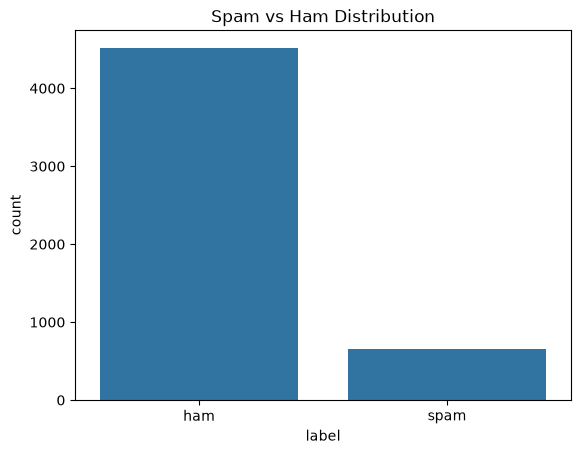

In [10]:
sns.countplot(data=df, x='label')
plt.title('Spam vs Ham Distribution')
plt.show()

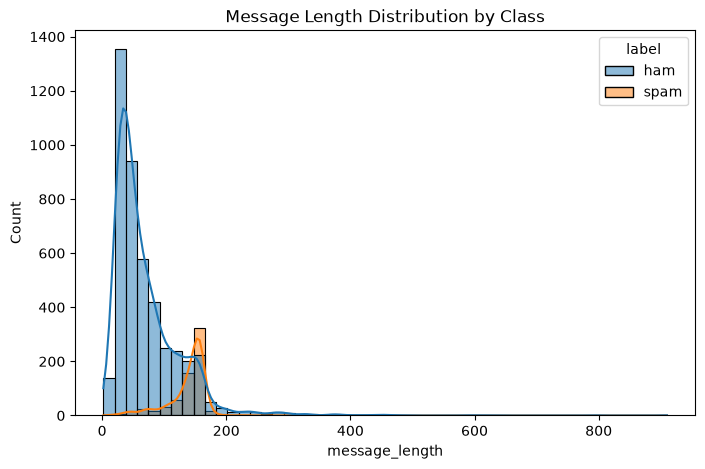

        count        mean        std   min    25%    50%    75%    max
label                                                                 
ham    4516.0   70.459256  56.358207   2.0   34.0   52.0   90.0  910.0
spam    653.0  137.891271  30.137753  13.0  132.0  149.0  157.0  224.0


In [11]:
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='message_length', hue='label', bins=50, kde=True)
plt.title('Message Length Distribution by Class')
plt.show()

print(df.groupby('label')['message_length'].describe())


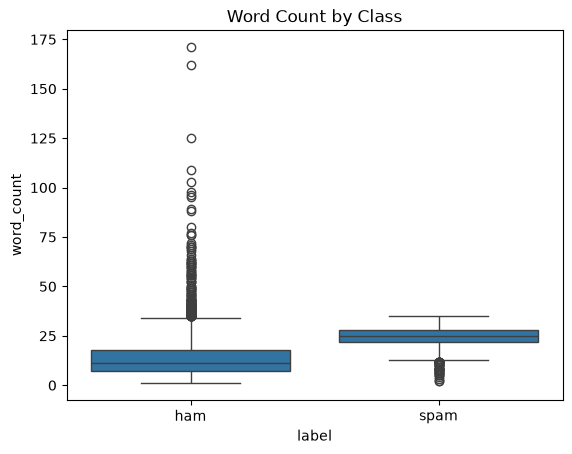

In [12]:
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
sns.boxplot(data=df, x='label', y='word_count')
plt.title('Word Count by Class')
plt.show()

**PREPROCESSING**

*text cleaning*

In [13]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_message'] = df['message'].apply(clean_text)
df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


*Stop words Removal*

In [14]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['clean_message'] = df['clean_message'].apply(remove_stopwords)
df[['message', 'clean_message']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sathw\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


In [15]:
df['label'] = df['label'].map({'ham': 0, 'spam': 1})
df['label'].value_counts()

label
0    4516
1     653
Name: count, dtype: int64

*Split*

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['clean_message']
y = df['label']

X_train_base, X_test_base, y_train_base, y_test_base = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train_base)

X_test_tfidf = tfidf.transform(X_test_base)

print("Train shape:", X_train_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)


Train shape: (4135, 5000)
Test shape: (1034, 5000)


**MODEL**

*Naive Bayes*

In [17]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

nb = MultinomialNB()
nb.fit(X_train_tfidf, y_train_base)
nb_pred = nb.predict(X_test_tfidf)

print("Naive Bayes Accuracy:", accuracy_score(y_test_base, nb_pred))
print("\nClassification Report:\n", classification_report(y_test_base, nb_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_base, nb_pred))
print("Train Accuracy:", nb.score(X_train_tfidf, y_train_base))
print("Test Accuracy:", nb.score(X_test_tfidf, y_test_base))

Naive Bayes Accuracy: 0.9661508704061895

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       903
           1       0.99      0.74      0.85       131

    accuracy                           0.97      1034
   macro avg       0.98      0.87      0.91      1034
weighted avg       0.97      0.97      0.96      1034

Confusion Matrix:
 [[902   1]
 [ 34  97]]
Train Accuracy: 0.9775090689238211
Test Accuracy: 0.9661508704061895


*LR*

In [18]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000,class_weight='balanced',random_state=42)
logreg.fit(X_train_tfidf, y_train_base)
logreg_pred = logreg.predict(X_test_tfidf)

print("Logistic Regression Accuracy:", accuracy_score(y_test_base, logreg_pred))
print("\nClassification Report:\n", classification_report(y_test_base, logreg_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test_base, logreg_pred))
print("Train Accuracy:", logreg.score(X_train_tfidf, y_train_base))
print("Test Accuracy:", logreg.score(X_test_tfidf, y_test_base))

Logistic Regression Accuracy: 0.9709864603481625

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.98       903
           1       0.87      0.90      0.89       131

    accuracy                           0.97      1034
   macro avg       0.93      0.94      0.94      1034
weighted avg       0.97      0.97      0.97      1034

Confusion Matrix:
 [[886  17]
 [ 13 118]]
Train Accuracy: 0.9879081015719468
Test Accuracy: 0.9709864603481625


*SVM*

In [19]:
from sklearn.svm import LinearSVC
svm = LinearSVC(class_weight='balanced',random_state=42)
svm.fit(X_train_tfidf, y_train_base)
svm_pred = svm.predict(X_test_tfidf)
print(classification_report(y_test_base, svm_pred))
print(confusion_matrix(y_test_base, svm_pred))
print("Train Accuracy:", svm.score(X_train_tfidf, y_train_base))
print("Test Accuracy:", svm.score(X_test_tfidf, y_test_base))


              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.93      0.88      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034

[[895   8]
 [ 16 115]]
Train Accuracy: 0.9990326481257558
Test Accuracy: 0.97678916827853


*TUNED SVM*

In [20]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

svm = LinearSVC(random_state=42)

param_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'class_weight': [None, 'balanced']
}

grid_svm = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

grid_svm.fit(X_train_tfidf, y_train_base)
best_svm = grid_svm.best_estimator_
tuned_pred = best_svm.predict(X_test_tfidf)

print("Best Parameters:", grid_svm.best_params_)
print("Best CV F1:", grid_svm.best_score_)
print("Tuned SVM Accuracy:", accuracy_score(y_test_base, tuned_pred))

print("\nClassification Report:\n")
print(classification_report(y_test_base, tuned_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test_base, tuned_pred))

Best Parameters: {'C': 2, 'class_weight': 'balanced'}
Best CV F1: 0.9110354894899197
Tuned SVM Accuracy: 0.97678916827853

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       903
           1       0.93      0.88      0.91       131

    accuracy                           0.98      1034
   macro avg       0.96      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034

Confusion Matrix:

[[895   8]
 [ 16 115]]


In [21]:
models_preds = {
    "Naive Bayes": nb_pred,
    "Logistic Regression": logreg_pred,
    "SVM": svm_pred,
    "Tuned SVM": tuned_pred,
   
}

results = []
for name, pred in models_preds.items():
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test_base, pred),
        "Precision": precision_score(y_test_base, pred, pos_label=1),
        "Recall": recall_score(y_test_base, pred, pos_label=1),
        "F1 Score": f1_score(y_test_base, pred, pos_label=1)
    })

results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False).reset_index(drop=True)
print(results_df)

                 Model  Accuracy  Precision    Recall  F1 Score
0            Tuned SVM  0.976789   0.934959  0.877863  0.905512
1                  SVM  0.976789   0.934959  0.877863  0.905512
2  Logistic Regression  0.970986   0.874074  0.900763  0.887218
3          Naive Bayes  0.966151   0.989796  0.740458  0.847162


In [22]:
import joblib

joblib.dump(best_svm, "spam_classifier_model.pkl")   
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model and vectorizer saved successfully!")

Model and vectorizer saved successfully!


In [23]:
def predict_email(text):
    cleaned = clean_text(text)
    cleaned = remove_stopwords(cleaned)
    vec = tfidf.transform([cleaned])
    prediction = best_svm.predict(vec)[0]   
    return prediction

In [24]:
email1 = """
Congratulations! You have won a $1,000 prize.
Click the link below immediately to claim your reward.
"""

print("Prediction:", predict_email(email1))

email2 = """
Hi Sathwik,

The meeting is scheduled for tomorrow at 10 AM.
Please join the meeting on time.

Regards,
Team
"""

print("Prediction:", predict_email(email2))

Prediction: 1
Prediction: 0


In [25]:
sample_spam = df[df['label'] == 1]['message'].iloc[0]
sample_ham = df[df['label'] == 0]['message'].iloc[0]

print("SPAM sample:\n", sample_spam)
print("\nHAM sample:\n", sample_ham)

SPAM sample:
 Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's

HAM sample:
 Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...


In [26]:
print("Prediction:", predict_email(sample_spam))
print("Prediction:", predict_email(sample_ham))

Prediction: 1
Prediction: 0


##  Final Model Selection

After comparing multiple machine learning models, **Tuned SVM** was selected as the final model for Email Spam Detection.

The model was tuned using **C = 2** and **class_weight = balanced**, achieving a **CV F1 Score of 91.10%**.

### Final Performance

* **Accuracy:** 97.68%
* **Precision:** 93%
* **Recall:** 88%
* **F1 Score:** 91%
* **Best CV F1:** 91.10%

The confusion matrix shows that the model correctly classified **895 Ham emails** and **115 Spam emails**, with only **8 Ham** and **16 Spam** emails misclassified.

Therefore, **Tuned SVM** was selected as the final model for the spam detection system.
